# 🎯 Customer Segmentation using Unsupervised Learning (Clustering)
**Objective:** Group retail customers into distinct segments based on their purchasing behavior (Annual Income and Spending Score) to enable targeted marketing strategies. We will use **K-Means** and **Agglomerative Hierarchical Clustering**, applying the Elbow Method to determine the optimal number of clusters.

In [1]:
# 1. Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


---
### 📂 Step 1: Load Data & Feature Selection
In clustering, identifiers like `CustomerID` are useless and will skew the distance calculations. Also, for clear marketing segmentation, we often focus on behavioral metrics. We will isolate numerical features for our model.

In [2]:
# Load Dataset
df = pd.read_csv('Customers (1).csv') # Update name if needed

# Display raw data
print(f"Raw Dataset Shape: {df.shape}")
display(df.head())

# Select relevant features for behavioral clustering
# We focus on Income and Spending Score to visualize clear 2D clusters
features = ['Annual Income ($)', 'Spending Score (1-100)']
X = df[features]

print("\nFeatures selected for clustering:")
display(X.head(3))

Raw Dataset Shape: (2000, 8)


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6



Features selected for clustering:


,Annual Income ($),Spending Score (1-100)
0,15000,39
1,35000,81
2,86000,6


---
### ⚙️ Step 2: Feature Scaling (Mandatory)
Distance-based algorithms (like K-Means) are highly sensitive to the magnitude of variables. We must use `StandardScaler` to equalize the weight of Income (thousands) and Spending Score (1-100).

In [3]:
# Initialize and apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(" Data Scaled Successfully!")

 Data Scaled Successfully!


---
### 🔍 Step 3: Determine Optimal Clusters (The Elbow Method)
We run K-Means for $K = 1$ to $10$ and plot the Within-Cluster-Sum-of-Squares (WCSS / Inertia) to find the "elbow" point, which indicates the optimal number of clusters.

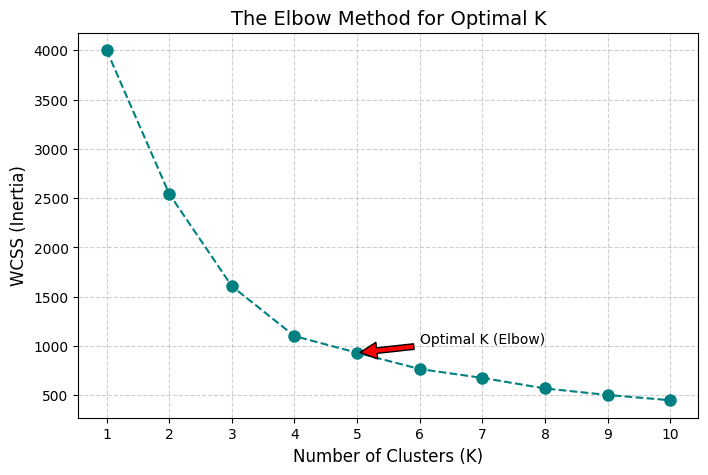

 Observation: The graph bends significantly at K=5. This is our optimal number of customer segments.


In [4]:
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker='o', linestyle='--', color='teal', markersize=8)
plt.title('The Elbow Method for Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate the optimal K (Usually 5 for this specific dataset structure)
plt.annotate('Optimal K (Elbow)', xy=(5, inertia_values[4]), xytext=(6, inertia_values[4] + 100),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.show()

print(" Observation: The graph bends significantly at K=5. This is our optimal number of customer segments.")

---
### 🚀 Step 4: Train K-Means Model & Visualize Segments
We will now fit the model with $K=5$ and visualize the resulting customer segments.

🏆 K-Means Silhouette Score: 0.366


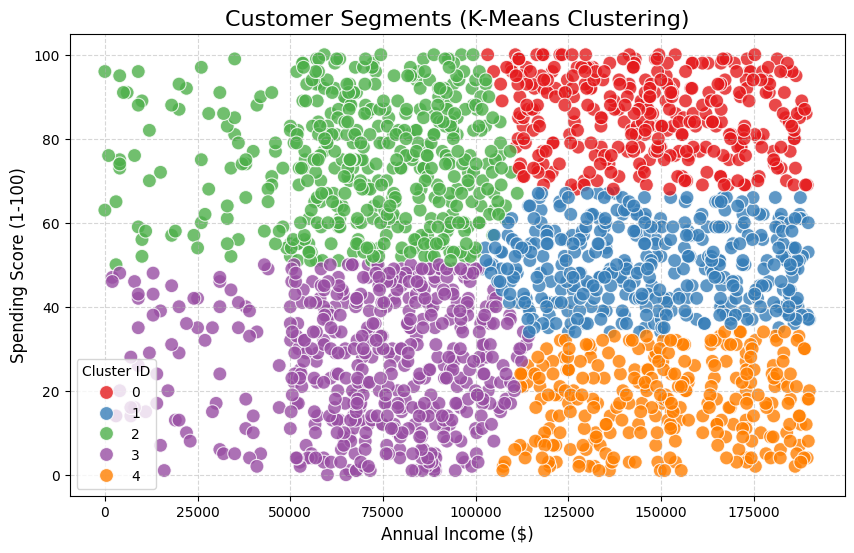

In [5]:
# Train the K-Means model
optimal_k = 5
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
cluster_labels = kmeans_model.fit_predict(X_scaled)

# Add cluster labels to our original dataframe for interpretability
df['KMeans_Cluster'] = cluster_labels

# Evaluate using Silhouette Score (closer to 1 is better)
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"🏆 K-Means Silhouette Score: {sil_score:.3f}")

# ==========================================
# 📈 Visualizing the Customer Segments
# ==========================================
plt.figure(figsize=(10, 6))

# Plot each cluster
sns.scatterplot(x='Annual Income ($)', y='Spending Score (1-100)', 
                hue='KMeans_Cluster', data=df, palette='Set1', s=100, alpha=0.8)

plt.title('Customer Segments (K-Means Clustering)', fontsize=16)
plt.xlabel('Annual Income ($)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
### 🧬 Step 5: Agglomerative Hierarchical Clustering
As an alternative, we apply Agglomerative Clustering (a bottom-up approach) to see if it yields a similar and stable segmentation pattern.

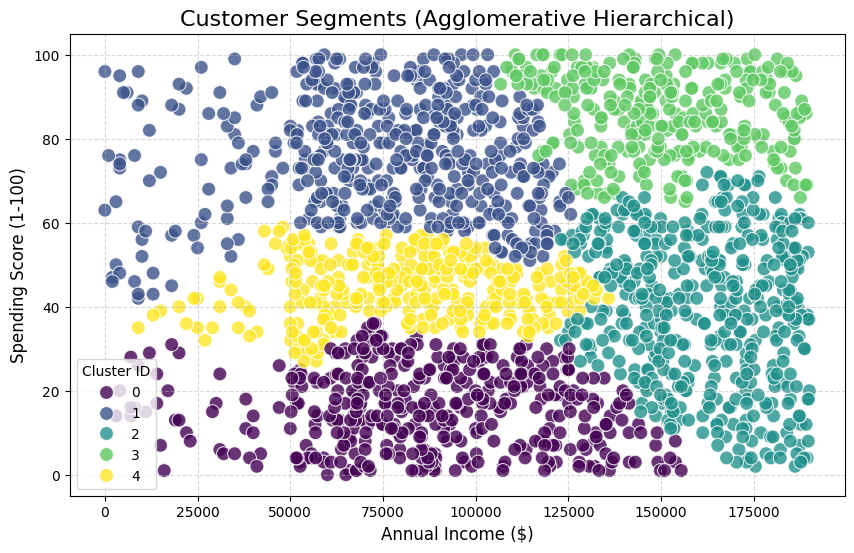

In [6]:
# Train Hierarchical Clustering
hc_model = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
hc_labels = hc_model.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = hc_labels

# Plotting the Hierarchical Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income ($)', y='Spending Score (1-100)', 
                hue='Hierarchical_Cluster', data=df, palette='viridis', s=100, alpha=0.8)

plt.title('Customer Segments (Agglomerative Hierarchical)', fontsize=16)
plt.xlabel('Annual Income ($)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()